# 08 – Build Sequences (30 Frames) NTHU

**Tujuan Notebook:**
Mengubah vektor fitur per-frame hasil `07_B` (shape `[N, 512]`) menjadi
**sekuens temporal** berbentuk `[N_seq, T=30, 512]` yang siap menjadi input LSTM.

**Alur kerja:**

07_B → [N, 512] per-frame features

↓ 08 → [N_seq, 30, 512] sequences ← NOTEBOOK INI

↓ 09 → Train LSTM

**Prinsip utama:**
- Sliding window T=30, Stride=10 (50% overlap)
- Batas video **WAJIB dihormati** — window tidak boleh melintasi antar video
- Subject-Independent Split dipertahankan: train=001,005 | val=002 | test=006
- Label sekuens = **Majority Voting** dari T frame
- Filter file `- Copy` sebagai documented data cleaning step

**Input:**  `features_nthuddd2/{MODEL}/{MODEL}_Features_{Split}_NTHUD.pt`
**Output:** `sequences_nthuddd2/{MODEL}/{MODEL}_Seq_{Split}_NTHUD.pt`

# 1. Import & Konfigurasi

Seluruh hyperparameter windowing dikumpulkan di satu tempat.

- `WINDOW_SIZE (T)` = 30 frame — satu sekuens mewakili ~1 detik rekaman (30 fps)
- `STRIDE` = 10 frame — lebih banyak sekuens, overlap lebih tinggi, cocok kalau butuh data lebih banyak untuk training LSTM 
- `LABEL_MODE` = `"majority"` — label sekuens ditentukan dari voting terbanyak 30 frame
- File `.pt` input berasal dari `07_B_Extract_Frame_Features_NTHU`

In [1]:
import os
import re
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from tqdm import tqdm

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 5)

# ─── PATH ──────────────────────────────────────────────────────────────────────
BASE_DIR       = r"C:\kuliah-sementara\SKRIPSI"
FEATURES_DIR   = os.path.join(BASE_DIR, "features_nthuddd2")
SEQUENCES_DIR  = os.path.join(BASE_DIR, "sequences_nthuddd2")
os.makedirs(SEQUENCES_DIR, exist_ok=True)

# ─── WINDOWING HYPERPARAMETER ─────────────────────────────────────────────────
WINDOW_SIZE        = 30       # T: jumlah frame per sekuens
STRIDE             = 10       # S: langkah geser window (dalam frame)
LABEL_MODE         = "majority"  # "majority" atau "last"
MIN_SEQ_PER_VIDEO  = 1        # Drop video jika menghasilkan < N sekuens

# ─── MODEL & SPLIT ─────────────────────────────────────────────────────────────
MODELS = ["CNN_BASIC", "MOBILENET", "VGG19", "SWIN"]
SPLITS = ["train", "val", "test"]

# ─── SUBJECT-INDEPENDENT SPLIT MAP (dari 05_Preprocessing) ────────────────────
# Train: 001, 005  |  Val: 002  |  Test: 006
SUBJECT_SPLIT_MAP = {
    "train": ["001", "005"],
    "val":   ["002"],
    "test":  ["006"],
}

# ─── LABEL MAP (sesuai urutan alfabet ImageFolder) ─────────────────────────────
# drowsy=0, notdrowsy=1
LABEL_MAP    = {0: "drowsy", 1: "notdrowsy"}
INV_LABEL    = {"drowsy": 0, "notdrowsy": 1}

# ─── PRINT KONFIGURASI ─────────────────────────────────────────────────────────
print("=" * 60)
print("  KONFIGURASI 08 – BUILD SEQUENCES")
print("=" * 60)
print(f"  Features dir   : {FEATURES_DIR}")
print(f"  Sequences dir  : {SEQUENCES_DIR}")
print(f"  Window size T  : {WINDOW_SIZE} frame")
print(f"  Stride         : {STRIDE} frame")
print(f"  Label mode     : {LABEL_MODE}")
print(f"  Models         : {MODELS}")
print(f"  Splits         : {SPLITS}")
print("=" * 60)

  KONFIGURASI 08 – BUILD SEQUENCES
  Features dir   : C:\kuliah-sementara\SKRIPSI\features_nthuddd2
  Sequences dir  : C:\kuliah-sementara\SKRIPSI\sequences_nthuddd2
  Window size T  : 30 frame
  Stride         : 10 frame
  Label mode     : majority
  Models         : ['CNN_BASIC', 'MOBILENET', 'VGG19', 'SWIN']
  Splits         : ['train', 'val', 'test']


# 2. Validasi File Input `.pt`

Sebelum memproses, pastikan semua file `.pt` hasil `07_B` sudah tersedia.
Jika ada yang hilang, proses dihentikan dengan pesan jelas.

Format nama file yang diharapkan:
`{MODEL}_Features_{Split}_NTHUD.pt`

Contoh: `SWIN_Features_Train_NTHUD.pt`

In [2]:
print("[VALIDASI] Mengecek keberadaan file .pt input...\n")

all_ok = True
for m in MODELS:
    for s in SPLITS:
        fname  = f"{m}_Features_{s.capitalize()}_NTHUD.pt"
        fpath  = os.path.join(FEATURES_DIR, m, fname)
        exists = os.path.exists(fpath)
        status = "  [OK]     " if exists else "  [MISSING]"
        if not exists:
            all_ok = False
        print(f"{status} {fname}")

print()
if not all_ok:
    raise FileNotFoundError(
        "Beberapa file .pt tidak ditemukan!\n"
        "Pastikan 07_B_Extract_Frame_Features_NTHU sudah dijalankan terlebih dahulu."
    )
print("✓ Semua file .pt tersedia. Siap membangun sekuens.")

[VALIDASI] Mengecek keberadaan file .pt input...

  [OK]      CNN_BASIC_Features_Train_NTHUD.pt
  [OK]      CNN_BASIC_Features_Val_NTHUD.pt
  [OK]      CNN_BASIC_Features_Test_NTHUD.pt
  [OK]      MOBILENET_Features_Train_NTHUD.pt
  [OK]      MOBILENET_Features_Val_NTHUD.pt
  [OK]      MOBILENET_Features_Test_NTHUD.pt
  [OK]      VGG19_Features_Train_NTHUD.pt
  [OK]      VGG19_Features_Val_NTHUD.pt
  [OK]      VGG19_Features_Test_NTHUD.pt
  [OK]      SWIN_Features_Train_NTHUD.pt
  [OK]      SWIN_Features_Val_NTHUD.pt
  [OK]      SWIN_Features_Test_NTHUD.pt

✓ Semua file .pt tersedia. Siap membangun sekuens.


# 3. Fungsi Parser Nama File NTHU 

Nama file NTHU mengikuti pola:


Contoh: `001_glasses_sleepyCombination_599_drowsy_L.jpg`

**Komponen yang diekstrak:**
| Komponen | Nilai Contoh | Keterangan |
|---|---|---|
| `subject_id` | `001` | ID subjek (3 digit) |
| `glasses_cond` | `glasses` / `noglasses` | Kondisi kacamata |
| `scenario` | `sleepyCombination` | Nama skenario perilaku |
| `frame_num` | `599` | Nomor frame dalam video |
| `eye_side` | `L` / `R` | Sisi mata |
| `video_id` | `001_glasses_sleepyCombination_L` | **Kunci batas window** |

Kombinasi `(subject_id, glasses_cond, scenario, eye_side)` = `video_id` unik.
Window **tidak boleh** melintasi dua `video_id` yang berbeda.

In [3]:
def parse_nthu_filename(path: str) -> dict:
    """
    Mem-parsing nama file NTHU menjadi komponen-komponennya.

    Pola  : {subj}_{glasses}_{scenario}_{framenum}_{label}_{eye}.jpg
    Contoh: 001_glasses_sleepyCombination_599_drowsy_L.jpg

    Returns dict dengan keys:
        subject_id, glasses_cond, scenario, frame_num, eye_side, video_id
    Atau None jika nama tidak sesuai pola.
    """
    basename = os.path.basename(path)

    # Hapus suffix ' - Copy' jika ada (Windows artifact)
    basename = re.sub(r'\s*-\s*Copy', '', basename)
    stem     = os.path.splitext(basename)[0].strip()

    # Regex: 001_glasses_sleepyCombination_599_drowsy_L
    pattern = r'^(\d{3})_(glasses|noglasses)_(.+?)_(\d+)_(drowsy|notdrowsy)_([LR])$'
    m = re.match(pattern, stem)
    if not m:
        return None

    subject_id   = m.group(1)
    glasses_cond = m.group(2)
    scenario     = m.group(3)
    frame_num    = int(m.group(4))
    eye_side     = m.group(6)
    video_id     = f"{subject_id}_{glasses_cond}_{scenario}_{eye_side}"

    return {
        "subject_id":   subject_id,
        "glasses_cond": glasses_cond,
        "scenario":     scenario,
        "frame_num":    frame_num,
        "eye_side":     eye_side,
        "video_id":     video_id,
    }


# ─── Tes Parser ────────────────────────────────────────────────────────────────
test_cases = [
    "001_glasses_sleepyCombination_599_drowsy_L.jpg",
    "005_noglasses_yawning_1234_notdrowsy_R.jpg",
    "006_glasses_slowBlinkWithNodding_508_drowsy - Copy_L.jpg",
    "invalid_filename.jpg",
]

print("[TES PARSER NAMA FILE]\n")
for p in test_cases:
    result = parse_nthu_filename(p)
    if result:
        print(f"  ✓ {p}")
        print(f"      video_id  : {result['video_id']}")
        print(f"      frame_num : {result['frame_num']}")
        print(f"      eye_side  : {result['eye_side']}\n")
    else:
        print(f"  ✗ {p} → TIDAK SESUAI POLA (akan di-skip)\n")

[TES PARSER NAMA FILE]

  ✓ 001_glasses_sleepyCombination_599_drowsy_L.jpg
      video_id  : 001_glasses_sleepyCombination_L
      frame_num : 599
      eye_side  : L

  ✓ 005_noglasses_yawning_1234_notdrowsy_R.jpg
      video_id  : 005_noglasses_yawning_R
      frame_num : 1234
      eye_side  : R

  ✓ 006_glasses_slowBlinkWithNodding_508_drowsy - Copy_L.jpg
      video_id  : 006_glasses_slowBlinkWithNodding_L
      frame_num : 508
      eye_side  : L

  ✗ invalid_filename.jpg → TIDAK SESUAI POLA (akan di-skip)



# 4. Data Cleaning — Filter File `- Copy` (TANYA)

Pada validasi di `07_B`, ditemukan file dengan suffix Windows `' - Copy'`
di folder test (subjek 006).

**Mengapa harus difilter sebelum windowing?**

Meski konten byte berbeda (lolos MD5 check di `05`), file `- Copy` memiliki
`frame_num` yang identik dengan versi aslinya dalam video yang sama.
Ketika frames diurutkan berdasarkan `frame_num`, dua entri dengan nomor
yang sama akan muncul berdampingan dalam satu window → duplikasi temporal
yang tidak representatif secara biologis.

In [4]:
def filter_copy_artifacts(
    paths: list,
    labels: torch.Tensor,
    features: torch.Tensor
):
    """
    Menghapus entry yang nama filenya mengandung ' - Copy' (Windows artifact).  (TANYA)

    Returns:
        paths_clean    : list path yang sudah bersih
        labels_clean   : Tensor label yang sudah bersih
        features_clean : Tensor fitur yang sudah bersih
        n_removed      : jumlah entry yang dihapus
    """
    clean_mask = [
        (" - Copy" not in p) and (" -Copy" not in p)
        for p in paths
    ]
    n_removed = len(paths) - sum(clean_mask)

    mask_tensor    = torch.tensor(clean_mask, dtype=torch.bool)
    paths_clean    = [p for p, keep in zip(paths, clean_mask) if keep]
    labels_clean   = labels[mask_tensor]
    features_clean = features[mask_tensor]

    return paths_clean, labels_clean, features_clean, n_removed


print("✓ Fungsi filter_copy_artifacts terdefinisi.")

✓ Fungsi filter_copy_artifacts terdefinisi.


# 5. Fungsi Grouping Per Video

Setelah loading `.pt`, frame-frame dikelompokkan berdasarkan `video_id`:

- Setiap grup = 1 skenario × 1 subjek × 1 sisi mata
- Frame dalam setiap grup **diurutkan ulang** berdasarkan `frame_num`
  untuk memastikan urutan temporal benar
- Sliding window **hanya dibuat dalam satu grup**

**Mengapa ini kritis?**
Pendekatan naif (langsung sliding window pada array flat) akan
**mencampur frame dari dua video berbeda** di posisi window yang
kebetulan berada di batas akhir video pertama dan awal video kedua.
Ini setara dengan merekam kantuk seseorang lalu tiba-tiba melompat
ke rekaman orang lain di tengah sekuens.

In [5]:
def group_frames_by_video(
    paths: list,
    labels: torch.Tensor,
    features: torch.Tensor
) -> dict:
    """
    Mengelompokkan frame berdasarkan video_id, lalu mengurutkan
    setiap grup berdasarkan frame_num (urutan temporal).

    Returns:
        dict[video_id] = list of dicts {frame_num, label, feature, subject_id}
    """
    groups  = defaultdict(list)
    skipped = 0

    for i, path in enumerate(paths):
        parsed = parse_nthu_filename(path)
        if parsed is None:
            skipped += 1
            continue

        groups[parsed["video_id"]].append({
            "frame_num":  parsed["frame_num"],
            "label":      int(labels[i].item()),
            "feature":    features[i],       # Tensor [512]
            "subject_id": parsed["subject_id"],
        })

    # Sort setiap grup berdasarkan frame_num
    for vid in groups:
        groups[vid].sort(key=lambda x: x["frame_num"])

    if skipped > 0:
        print(f"  ⚠  {skipped} frame di-skip (nama tidak sesuai pola NTHU)")

    return dict(groups)


print("✓ Fungsi group_frames_by_video terdefinisi.")

✓ Fungsi group_frames_by_video terdefinisi.


# 6. Fungsi Sliding Window + Majority Voting

Fungsi inti yang membangun sekuens dari satu video.

**Sliding Window:**

Video: [f1, f2, f3, ..., f_N]

T=30, stride=10

Window 1: [f1 ... f30] → label = majority(f1..f30)

Window 2: [f16 ... f45] → label = majority(f16..f45)

Window 3: [f31 ... f60] → label = majority(f31..f60)


**Majority Voting:**
Label sekuens = kelas yang paling banyak muncul di antara T frame.
- 20 drowsy + 10 notdrowsy → label = **drowsy**
- Ini lebih robust dibanding hanya mengambil label frame terakhir
- Relevan secara medis: kantuk bersifat **gradual**, bukan biner per-frame

**Boundary Rule:**
Sisa frame di akhir video yang kurang dari T diabaikan (tanpa padding).
Padding mengisi dengan data fiktif yang bisa merusak pola temporal.

In [6]:
def sliding_window_on_video(
    frames: list,
    window_size: int = 30,
    stride:      int = 10,
    label_mode:  str = "majority"
) -> tuple:
    """
    Membuat sliding windows dari satu video.

    Args:
        frames      : list frame dict, sudah sorted berdasarkan frame_num
        window_size : T, jumlah frame per window
        stride      : jarak antar window
        label_mode  : 'majority' atau 'last'

    Returns:
        seq_features : Tensor [N_win, T, 512]
        seq_labels   : Tensor [N_win]
        seq_meta     : list of dict (metadata tiap window untuk analisis)
    """
    N = len(frames)
    if N < window_size:
        return None, None, None  # Video terlalu pendek

    seq_features = []
    seq_labels   = []
    seq_meta     = []

    for start in range(0, N - window_size + 1, stride):
        window = frames[start : start + window_size]

        # Stack fitur menjadi [T, 512]
        feat_stack = torch.stack([f["feature"] for f in window], dim=0)

        # Tentukan label window
        if label_mode == "majority":
            all_labels = [f["label"] for f in window]
            label_win  = Counter(all_labels).most_common(1)[0][0]
        elif label_mode == "last":
            label_win  = window[-1]["label"]
        else:
            raise ValueError(f"label_mode tidak dikenal: '{label_mode}'")

        # Hitung komposisi label dalam window ini
        n_drowsy    = sum(1 for f in window if f["label"] == 0)
        n_notdrowsy = sum(1 for f in window if f["label"] == 1)

        seq_features.append(feat_stack)
        seq_labels.append(label_win)
        seq_meta.append({
            "start_frame":  window[0]["frame_num"],
            "end_frame":    window[-1]["frame_num"],
            "n_drowsy":     n_drowsy,
            "n_notdrowsy":  n_notdrowsy,
            "label":        label_win,
            "is_mixed":     (n_drowsy > 0 and n_notdrowsy > 0),  # window transisi
        })

    if not seq_features:
        return None, None, None

    return (
        torch.stack(seq_features, dim=0),   # [N_win, T, 512]
        torch.tensor(seq_labels),            # [N_win]
        seq_meta,
    )


print("✓ Fungsi sliding_window_on_video terdefinisi.")

✓ Fungsi sliding_window_on_video terdefinisi.


# 7. Fungsi Build Sequences — Satu File `.pt`

Fungsi orchestrator yang menggabungkan semua langkah:

1. **Load** file `.pt` dari `07_B`
2. **Data Cleaning** — filter file `- Copy`
3. **Validasi Subject-Split** — pastikan tidak ada subjek yang salah folder
4. **Group** per video
5. **Sliding window** per video (boundary-aware)
6. **Concatenate** semua window
7. **Save** ke `.pt` baru dengan metadata lengkap

In [7]:
def build_sequences_from_pt(
    model_name:        str,
    split_name:        str,
    window_size:       int = 30,
    stride:            int = 10,
    label_mode:        str = "majority",
    min_seq_per_video: int = 1,
) -> dict:
    """
    Load features .pt → build sequences → save sequences .pt

    Returns:
        dict ringkasan statistik, atau None jika gagal
    """
    # ── 1. LOAD ──────────────────────────────────────────────────────────────
    in_fname = f"{model_name}_Features_{split_name.capitalize()}_NTHUD.pt"
    in_path  = os.path.join(FEATURES_DIR, model_name, in_fname)
    data     = torch.load(in_path, map_location="cpu")

    features = data["features"]   # [N, 512]
    labels   = data["labels"]     # [N]
    paths    = data["paths"]      # list of N path string

    print(f"\n  Loaded   : {in_fname}")
    print(f"  Frames   : {features.shape[0]:,}")

    # Cek apakah features sudah ternormalisasi dari 07_B
    feat_mean = features.mean().item()
    feat_std  = features.std().item()
    print(f"  Feat mean/std : {feat_mean:.4f} / {feat_std:.4f}")

    # ── 2. DATA CLEANING: Filter '- Copy' ────────────────────────────────────
    paths, labels, features, n_copy = filter_copy_artifacts(paths, labels, features)
    if n_copy > 0:
        print(f"  🧹 Filtered  : {n_copy} file '- Copy' dihapus dari {split_name}")
    else:
        print(f"  ✓ Clean      : Tidak ada file '- Copy'")

    # ── 3. VALIDASI SUBJECT-SPLIT INTEGRITY ──────────────────────────────────
    expected_subjects = set(SUBJECT_SPLIT_MAP[split_name])
    found_subjects    = set()
    wrong_subjects    = set()

    for p in paths:
        parsed = parse_nthu_filename(p)
        if parsed:
            subj = parsed["subject_id"]
            found_subjects.add(subj)
            if subj not in expected_subjects:
                wrong_subjects.add(subj)

    if wrong_subjects:
        print(f"  ⚠ PERINGATAN: Subjek tidak terduga di {split_name}: {wrong_subjects}")
        print(f"     Expected: {expected_subjects} | Found: {found_subjects}")
    else:
        print(f"  ✓ Subjects   : {sorted(found_subjects)} (sesuai expected {sorted(expected_subjects)})")

    # ── 4. GROUP PER VIDEO ───────────────────────────────────────────────────
    groups = group_frames_by_video(paths, labels, features)
    print(f"  ✓ Video groups : {len(groups):,}")

    # Distribusi panjang video
    vid_lengths = [len(v) for v in groups.values()]
    print(f"  Video length  : min={min(vid_lengths)} | max={max(vid_lengths)} | mean={np.mean(vid_lengths):.1f}")

    # ── 5. SLIDING WINDOW PER VIDEO ──────────────────────────────────────────
    all_seq_features = []
    all_seq_labels   = []
    all_seq_meta     = []
    dropped_videos   = 0
    n_mixed_windows  = 0

    for video_id, frames in tqdm(groups.items(), desc=f"  Windowing {split_name}", leave=False):
        seq_feats, seq_labs, seq_metas = sliding_window_on_video(
            frames, window_size, stride, label_mode
        )

        if seq_feats is None or len(seq_feats) < min_seq_per_video:
            dropped_videos += 1
            continue

        all_seq_features.append(seq_feats)
        all_seq_labels.append(seq_labs)
        all_seq_meta.extend(seq_metas)
        n_mixed_windows += sum(1 for m in seq_metas if m["is_mixed"])

    if not all_seq_features:
        print(f"  ✗ TIDAK ada sekuens berhasil dibuat untuk {model_name}/{split_name}!")
        return None

    # ── 6. CONCATENATE ───────────────────────────────────────────────────────
    final_features = torch.cat(all_seq_features, dim=0)   # [N_seq, T, 512]
    final_labels   = torch.cat(all_seq_labels,   dim=0)   # [N_seq]

    n_drowsy    = int((final_labels == 0).sum())
    n_notdrowsy = int((final_labels == 1).sum())
    n_total     = len(final_labels)
    balance_pct = n_drowsy / n_total * 100 if n_total > 0 else 0

    # ── 7. SAVE ──────────────────────────────────────────────────────────────
    out_dir  = os.path.join(SEQUENCES_DIR, model_name)
    os.makedirs(out_dir, exist_ok=True)

    out_fname = f"{model_name}_Seq_{split_name.capitalize()}_NTHUD.pt"
    out_path  = os.path.join(out_dir, out_fname)

    torch.save({
        "features":         final_features,
        "labels":           final_labels,
        "window_size":      window_size,
        "stride":           stride,
        "label_mode":       label_mode,
        "model":            model_name,
        "split":            split_name,
        "n_seq":            n_total,
        "n_drowsy":         n_drowsy,
        "n_notdrowsy":      n_notdrowsy,
        "n_videos":         len(groups) - dropped_videos,
        "n_mixed_windows":  n_mixed_windows,
        "meta":             all_seq_meta,
    }, out_path)

    print(f"  ✓ Saved      : {out_fname}")
    print(f"     Shape     : {list(final_features.shape)}")
    print(f"     N sekuens : {n_total:,}  (drowsy={n_drowsy:,} | notdrowsy={n_notdrowsy:,})")
    print(f"     Balance   : {balance_pct:.1f}% drowsy")
    print(f"     Mixed win : {n_mixed_windows:,} (windows transisi label)")

    if dropped_videos > 0:
        print(f"  ⚠ Dropped   : {dropped_videos} video (frame < {window_size})")

    return {
        "model": model_name, "split": split_name,
        "n_seq": n_total, "n_drowsy": n_drowsy,
        "n_notdrowsy": n_notdrowsy,
        "n_videos": len(groups) - dropped_videos,
        "dropped_videos": dropped_videos,
        "n_mixed_windows": n_mixed_windows,
    }


print("✓ Fungsi build_sequences_from_pt terdefinisi.")

✓ Fungsi build_sequences_from_pt terdefinisi.


# 8. Eksekusi — Build Semua Sekuens

Iterasi semua kombinasi model × split.
Proses ini **tidak membutuhkan GPU** — semua operasi adalah tensor manipulation di CPU.

Estimasi waktu: ~2–5 menit tergantung kecepatan disk.

In [8]:
all_stats = []

for model_name in MODELS:
    print(f"\n{'='*65}")
    print(f"  MODEL: {model_name}")
    print(f"{'='*65}")

    for split_name in SPLITS:
        result = build_sequences_from_pt(
            model_name        = model_name,
            split_name        = split_name,
            window_size       = WINDOW_SIZE,
            stride            = STRIDE,
            label_mode        = LABEL_MODE,
            min_seq_per_video = MIN_SEQ_PER_VIDEO,
        )
        if result:
            all_stats.append(result)

        gc.collect()  # Bebaskan memori setelah tiap split

print(f"\n{'='*65}")
print("  ✓ SEMUA SEKUENS BERHASIL DIBANGUN")
print(f"{'='*65}")


  MODEL: CNN_BASIC

  Loaded   : CNN_BASIC_Features_Train_NTHUD.pt
  Frames   : 81,270
  Feat mean/std : 0.0324 / 0.0992
  ✓ Clean      : Tidak ada file '- Copy'
  ✓ Subjects   : ['001', '005'] (sesuai expected ['001', '005'])
  ✓ Video groups : 32
  Video length  : min=1850 | max=3302 | mean=2539.7


  ✓ Saved      : CNN_BASIC_Seq_Train_NTHUD.pt
     Shape     : [8053, 30, 512]
     N sekuens : 8,053  (drowsy=4,502 | notdrowsy=3,551)
     Balance   : 55.9% drowsy
     Mixed win : 228 (windows transisi label)

  Loaded   : CNN_BASIC_Features_Val_NTHUD.pt
  Frames   : 36,734
  Feat mean/std : 0.0330 / 0.1208
  ✓ Clean      : Tidak ada file '- Copy'
  ✓ Subjects   : ['002'] (sesuai expected ['002'])
  ✓ Video groups : 16
  Video length  : min=1771 | max=2879 | mean=2295.9


  ✓ Saved      : CNN_BASIC_Seq_Val_NTHUD.pt
     Shape     : [3634, 30, 512]
     N sekuens : 3,634  (drowsy=2,100 | notdrowsy=1,534)
     Balance   : 57.8% drowsy
     Mixed win : 88 (windows transisi label)

  Loaded   : CNN_BASIC_Features_Test_NTHUD.pt
  Frames   : 13,183
  Feat mean/std : 0.0239 / 0.0724
  🧹 Filtered  : 8 file '- Copy' dihapus dari test
  ✓ Subjects   : ['006'] (sesuai expected ['006'])
  ✓ Video groups : 6
  Video length  : min=1022 | max=2849 | mean=2195.8


  ✓ Saved      : CNN_BASIC_Seq_Test_NTHUD.pt


     Shape     : [1302, 30, 512]
     N sekuens : 1,302  (drowsy=548 | notdrowsy=754)
     Balance   : 42.1% drowsy
     Mixed win : 28 (windows transisi label)

  MODEL: MOBILENET

  Loaded   : MOBILENET_Features_Train_NTHUD.pt
  Frames   : 81,270
  Feat mean/std : 0.2625 / 0.3990
  ✓ Clean      : Tidak ada file '- Copy'
  ✓ Subjects   : ['001', '005'] (sesuai expected ['001', '005'])
  ✓ Video groups : 32
  Video length  : min=1850 | max=3302 | mean=2539.7


...


  MODEL: SWIN

  Loaded   : SWIN_Features_Train_NTHUD.pt
  Frames   : 81,270
  Feat mean/std : 0.2108 / 0.5154
  ✓ Clean      : Tidak ada file '- Copy'
  ✓ Subjects   : ['001', '005'] (sesuai expected ['001', '005'])
  ✓ Video groups : 32
  Video length  : min=1850 | max=3302 | mean=2539.7


  ✓ Saved      : SWIN_Seq_Train_NTHUD.pt
     Shape     : [8053, 30, 512]
     N sekuens : 8,053  (drowsy=4,502 | notdrowsy=3,551)
     Balance   : 55.9% drowsy
     Mixed win : 228 (windows transisi label)

  Loaded   : SWIN_Features_Val_NTHUD.pt
  Frames   : 36,734
  Feat mean/std : 0.2099 / 0.5161
  ✓ Clean      : Tidak ada file '- Copy'
  ✓ Subjects   : ['002'] (sesuai expected ['002'])
  ✓ Video groups : 16
  Video length  : min=1771 | max=2879 | mean=2295.9


  ✓ Saved      : SWIN_Seq_Val_NTHUD.pt
     Shape     : [3634, 30, 512]
     N sekuens : 3,634  (drowsy=2,100 | notdrowsy=1,534)
     Balance   : 57.8% drowsy
     Mixed win : 88 (windows transisi label)

  Loaded   : SWIN_Features_Test_NTHUD.pt
  Frames   : 13,183
  Feat mean/std : 0.2213 / 0.5362
  🧹 Filtered  : 8 file '- Copy' dihapus dari test
  ✓ Subjects   : ['006'] (sesuai expected ['006'])
  ✓ Video groups : 6
  Video length  : min=1022 | max=2849 | mean=2195.8


  ✓ Saved      : SWIN_Seq_Test_NTHUD.pt


     Shape     : [1302, 30, 512]
     N sekuens : 1,302  (drowsy=548 | notdrowsy=754)
     Balance   : 42.1% drowsy
     Mixed win : 28 (windows transisi label)

  ✓ SEMUA SEKUENS BERHASIL DIBANGUN


# 9. Ringkasan Statistik Sekuens

Tabel jumlah sekuens yang dihasilkan per model per split,
beserta distribusi kelas dan jumlah **mixed windows** (window yang
berisi campuran frame drowsy dan notdrowsy — window transisi).

Mixed windows penting untuk diketahui karena merupakan sample
yang paling ambigu dan paling sering menyebabkan false prediction.

In [9]:
print("=" * 90)
print(f"{'RINGKASAN SEKUENS':^90}")
print(f"  Window={WINDOW_SIZE} | Stride={STRIDE} | Label={LABEL_MODE}")
print("=" * 90)
print(f"  {'Model':<12} {'Split':<7} {'N Seq':>9} {'Drowsy':>9} {'NotDrowsy':>11}"
      f" {'Balance':>9} {'Mixed Win':>11} {'Videos':>8}")
print("-" * 90)

grand_total = 0
for s in all_stats:
    total   = s["n_seq"]
    balance = s["n_drowsy"] / total * 100 if total > 0 else 0
    print(
        f"  {s['model']:<12} {s['split']:<7} {total:>9,} "
        f"{s['n_drowsy']:>9,} {s['n_notdrowsy']:>11,} "
        f"{balance:>8.1f}% {s['n_mixed_windows']:>11,} "
        f"{s['n_videos']:>8,}"
    )
    grand_total += total

print("-" * 90)
print(f"  {'GRAND TOTAL':<19} {grand_total:>9,}")
print("=" * 90)
print(f"\n[INFO] Semua file tersimpan di: {SEQUENCES_DIR}")

                                    RINGKASAN SEKUENS                                     
  Window=30 | Stride=10 | Label=majority
  Model        Split       N Seq    Drowsy   NotDrowsy   Balance   Mixed Win   Videos
------------------------------------------------------------------------------------------
  CNN_BASIC    train       8,053     4,502       3,551     55.9%         228       32
  CNN_BASIC    val         3,634     2,100       1,534     57.8%          88       16
  CNN_BASIC    test        1,302       548         754     42.1%          28        6
  MOBILENET    train       8,053     4,502       3,551     55.9%         228       32
  MOBILENET    val         3,634     2,100       1,534     57.8%          88       16
  MOBILENET    test        1,302       548         754     42.1%          28        6
  VGG19        train       8,053     4,502       3,551     55.9%         228       32
  VGG19        val         3,634     2,100       1,534     57.8%          88       16
  V

# 10. Verifikasi Integritas File Output

Load ulang setiap file `.pt` dan verifikasi:
- **Shape** tensor: harus `[N_seq, T=30, 512]`
- **NaN / Inf**: tidak boleh ada nilai tidak valid
- **Label**: hanya berisi `0` (drowsy) atau `1` (notdrowsy)
- **Metadata**: kunci wajib tersimpan

Jika ada yang gagal, jangan lanjut ke notebook `09`.

In [10]:
print("=" * 65)
print("  VERIFIKASI INTEGRITAS FILE SEKUENS OUTPUT")
print("=" * 65)

all_valid = True

for model_name in MODELS:
    print(f"\n  [{model_name}]")

    for split_name in SPLITS:
        fname = f"{model_name}_Seq_{split_name.capitalize()}_NTHUD.pt"
        fpath = os.path.join(SEQUENCES_DIR, model_name, fname)

        if not os.path.exists(fpath):
            print(f"    ✗ TIDAK ADA  : {fname}")
            all_valid = False
            continue

        data  = torch.load(fpath, map_location="cpu")
        feats = data["features"]
        labs  = data["labels"]

        # Cek shape: harus [N, 30, 512]
        shape_ok = (
            feats.ndim == 3 and
            feats.shape[1] == WINDOW_SIZE and
            feats.shape[2] == 512
        )

        # Cek NaN / Inf
        nan_ok = not (torch.isnan(feats).any() or torch.isinf(feats).any())

        # Cek label: hanya 0 dan 1
        unique_labels = sorted(labs.unique().tolist())
        label_ok      = all(int(l) in [0, 1] for l in unique_labels)

        # Cek metadata wajib
        required_keys = ["window_size", "stride", "label_mode", "model", "split",
                         "n_seq", "n_drowsy", "n_notdrowsy"]
        meta_ok = all(k in data for k in required_keys)

        status = "✓" if (shape_ok and nan_ok and label_ok and meta_ok) else "✗"
        if status == "✗":
            all_valid = False

        print(
            f"    {status} {split_name:<5}  "
            f"Shape: {list(feats.shape)}  "
            f"NaN/Inf: {'OK' if nan_ok else '⚠ ERROR'}  "
            f"Labels: {unique_labels} {'OK' if label_ok else '⚠ ERROR'}  "
            f"Meta: {'OK' if meta_ok else '⚠ INCOMPLETE'}"
        )

print(f"\n{'='*65}")
if all_valid:
    print("  ✓ SEMUA FILE VALID — Siap untuk training LSTM di Notebook 09")
else:
    print("  ✗ ADA FILE BERMASALAH — Cek log di atas sebelum lanjut")
print("=" * 65)

  VERIFIKASI INTEGRITAS FILE SEKUENS OUTPUT

  [CNN_BASIC]
    ✓ train  Shape: [8053, 30, 512]  NaN/Inf: OK  Labels: [0, 1] OK  Meta: OK
    ✓ val    Shape: [3634, 30, 512]  NaN/Inf: OK  Labels: [0, 1] OK  Meta: OK
    ✓ test   Shape: [1302, 30, 512]  NaN/Inf: OK  Labels: [0, 1] OK  Meta: OK

  [MOBILENET]
    ✓ train  Shape: [8053, 30, 512]  NaN/Inf: OK  Labels: [0, 1] OK  Meta: OK
    ✓ val    Shape: [3634, 30, 512]  NaN/Inf: OK  Labels: [0, 1] OK  Meta: OK
    ✓ test   Shape: [1302, 30, 512]  NaN/Inf: OK  Labels: [0, 1] OK  Meta: OK

  [VGG19]
    ✓ train  Shape: [8053, 30, 512]  NaN/Inf: OK  Labels: [0, 1] OK  Meta: OK
    ✓ val    Shape: [3634, 30, 512]  NaN/Inf: OK  Labels: [0, 1] OK  Meta: OK
    ✓ test   Shape: [1302, 30, 512]  NaN/Inf: OK  Labels: [0, 1] OK  Meta: OK

  [SWIN]
    ✓ train  Shape: [8053, 30, 512]  NaN/Inf: OK  Labels: [0, 1] OK  Meta: OK
    ✓ val    Shape: [3634, 30, 512]  NaN/Inf: OK  Labels: [0, 1] OK  Meta: OK
    ✓ test   Shape: [1302, 30, 512]  NaN/Inf: O

# 11. Visualisasi Distribusi Kelas

Bar chart distribusi sekuens `drowsy` vs `notdrowsy` per model per split.

Tujuan:
- Deteksi **class imbalance** yang mungkin mempengaruhi training LSTM
- Jika imbalance > 60:40, pertimbangkan `class_weight` di loss function `09`
- Plot disimpan otomatis sebagai dokumentasi pipeline

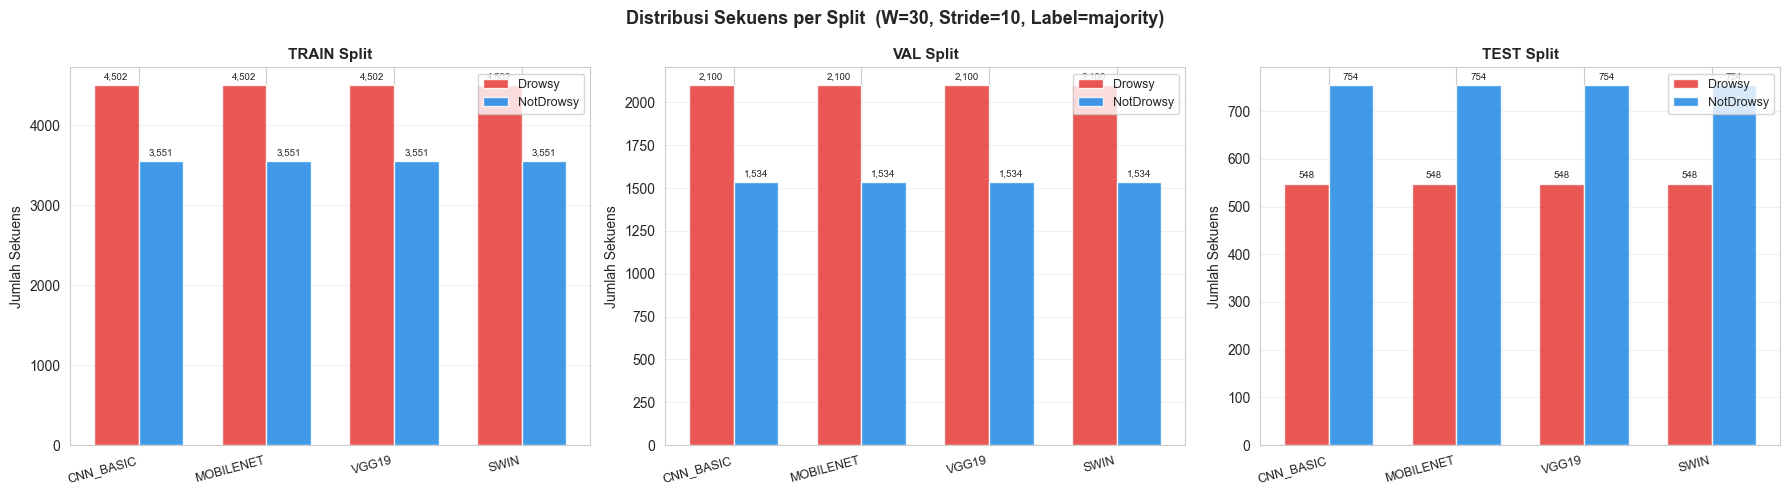

✓ Plot tersimpan di: C:\kuliah-sementara\SKRIPSI\sequences_nthuddd2\distribusi_sekuens.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"Distribusi Sekuens per Split  (W={WINDOW_SIZE}, Stride={STRIDE}, Label={LABEL_MODE})",
    fontsize=13, fontweight="bold"
)

for ax_idx, split_name in enumerate(SPLITS):
    ax         = axes[ax_idx]
    split_data = [s for s in all_stats if s["split"] == split_name]

    if not split_data:
        ax.set_title(f"{split_name.upper()} — No Data")
        continue

    model_labels     = [s["model"] for s in split_data]
    drowsy_counts    = [s["n_drowsy"]    for s in split_data]
    notdrowsy_counts = [s["n_notdrowsy"] for s in split_data]

    x     = np.arange(len(model_labels))
    width = 0.35

    bars_d  = ax.bar(x - width/2, drowsy_counts,    width,
                     label="Drowsy",    color="#E53935", alpha=0.85)
    bars_nd = ax.bar(x + width/2, notdrowsy_counts, width,
                     label="NotDrowsy", color="#1E88E5", alpha=0.85)

    # Label nilai di atas bar
    for bar in bars_d + bars_nd:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2., h + max(drowsy_counts + notdrowsy_counts) * 0.01,
                f"{int(h):,}", ha="center", va="bottom", fontsize=7
            )

    ax.set_title(f"{split_name.upper()} Split", fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=15, ha="right", fontsize=9)
    ax.set_ylabel("Jumlah Sekuens")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_path = os.path.join(SEQUENCES_DIR, "distribusi_sekuens.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Plot tersimpan di: {save_path}")

# CEK DISTRIBUSI — WARNING JIKA TEST SET FLIP POLARITAS

In [17]:
print("=" * 60)
print(" CEK DISTRIBUSI KELAS ANTAR SPLIT")
print("=" * 60)

for s in all_stats:
    balance = s["n_drowsy"] / s["n_seq"] * 100
    flag = ""
    if balance < 45 or balance > 60:
        flag = "  ⚠ IMBALANCE!"
    print(f"  {s['model']:<12} {s['split']:<6} drowsy={balance:.1f}%{flag}")

# Cek apakah test set berlawanan arah dengan train
train_balances = [s["n_drowsy"]/s["n_seq"] for s in all_stats if s["split"] == "train"]
test_balances  = [s["n_drowsy"]/s["n_seq"] for s in all_stats if s["split"] == "test"]

train_avg = sum(train_balances) / len(train_balances)
test_avg  = sum(test_balances) / len(test_balances)

if (train_avg > 0.5 and test_avg < 0.5) or (train_avg < 0.5 and test_avg > 0.5):
    print()
    print("     KRITIS: Polaritas kelas TRAIN vs TEST berlawanan!")
    print(f"     Train avg drowsy: {train_avg*100:.1f}%")
    print(f"     Test  avg drowsy: {test_avg*100:.1f}%")
    print("  → Di notebook 09, WAJIB pakai class_weight di loss function.")
    print("  → Jangan evaluasi hanya dengan Accuracy — gunakan F1-Score & Confusion Matrix.")

 CEK DISTRIBUSI KELAS ANTAR SPLIT
  CNN_BASIC    train  drowsy=55.9%
  CNN_BASIC    val    drowsy=57.8%
  CNN_BASIC    test   drowsy=42.1%  ⚠ IMBALANCE!
  MOBILENET    train  drowsy=55.9%
  MOBILENET    val    drowsy=57.8%
  MOBILENET    test   drowsy=42.1%  ⚠ IMBALANCE!
  VGG19        train  drowsy=55.9%
  VGG19        val    drowsy=57.8%
  VGG19        test   drowsy=42.1%  ⚠ IMBALANCE!
  SWIN         train  drowsy=55.9%
  SWIN         val    drowsy=57.8%
  SWIN         test   drowsy=42.1%  ⚠ IMBALANCE!

     KRITIS: Polaritas kelas TRAIN vs TEST berlawanan!
     Train avg drowsy: 55.9%
     Test  avg drowsy: 42.1%
  → Di notebook 09, WAJIB pakai class_weight di loss function.
  → Jangan evaluasi hanya dengan Accuracy — gunakan F1-Score & Confusion Matrix.


Argumen "Tetap Harus Diwaspadai"

Masalah sebenarnya bukan pada angka imbalance-nya sendiri, tapi pada arah polaritasnya yang terbalik:

Model dilatih di kondisi "dunia lebih banyak drowsy" (55.9%)

Lalu dievaluasi di kondisi "dunia lebih banyak notdrowsy" (42.1%)

Efek yang bisa terjadi: model punya prior bias ke drowsy karena training. Saat test set justru didominasi notdrowsy, model mungkin tetap over-predict drowsy → False Positive tinggi (orang tidak ngantuk tapi diprediksi ngantuk). Untuk safety system seperti deteksi kantuk pengemudi, False Positive yang tinggi justru merusak kepercayaan pengguna.

# 12. Analisis Mixed Windows (Transisi Label)

**Mixed window** = window yang mengandung campuran frame drowsy dan notdrowsy.
Window ini adalah "zona abu-abu" yang mewakili transisi kondisi pengemudi.

Informasi ini berguna untuk:
1. Mengetahui seberapa banyak sample yang ambigu secara label
2. Memutuskan apakah perlu menerapkan **label smoothing** di loss function
3. Bahan diskusi di bab Analisis skripsi tentang ambiguitas temporal kantuk

Rumus ambiguity ratio:
`ambiguity_ratio = n_mixed_windows / n_total_sequences`

In [13]:
print("=" * 70)
print(f"{'ANALISIS MIXED WINDOWS (TRANSISI LABEL)':^70}")
print("=" * 70)
print(f"  {'Model':<12} {'Split':<7} {'Total Seq':>10} {'Mixed Win':>11} {'Ambiguity %':>13}")
print("-" * 70)

for s in all_stats:
    total = s["n_seq"]
    mixed = s["n_mixed_windows"]
    ratio = mixed / total * 100 if total > 0 else 0
    flag  = "  ← perlu perhatian" if ratio > 30 else ""
    print(f"  {s['model']:<12} {s['split']:<7} {total:>10,} {mixed:>11,} {ratio:>12.1f}%{flag}")

print("-" * 70)
print("""
  Interpretasi:
  - < 20% : Mixed windows sedikit, label mayoritas cukup representatif
  - 20-40% : Sedang. Pertimbangkan label smoothing atau threshold majority voting
  - > 40%  : Tinggi. Kemungkinan banyak video transisi yang panjang.
              Pertimbangkan stride lebih besar atau drop mixed windows.
""")
print("=" * 70)

               ANALISIS MIXED WINDOWS (TRANSISI LABEL)                
  Model        Split    Total Seq   Mixed Win   Ambiguity %
----------------------------------------------------------------------
  CNN_BASIC    train        8,053         228          2.8%
  CNN_BASIC    val          3,634          88          2.4%
  CNN_BASIC    test         1,302          28          2.2%
  MOBILENET    train        8,053         228          2.8%
  MOBILENET    val          3,634          88          2.4%
  MOBILENET    test         1,302          28          2.2%
  VGG19        train        8,053         228          2.8%
  VGG19        val          3,634          88          2.4%
  VGG19        test         1,302          28          2.2%
  SWIN         train        8,053         228          2.8%
  SWIN         val          3,634          88          2.4%
  SWIN         test         1,302          28          2.2%
----------------------------------------------------------------------

  Inte

# 13. Konfirmasi Akhir & Instruksi Notebook Berikutnya

Ringkasan file yang siap digunakan oleh Notebook 09.

In [14]:
print("=" * 65)
print("  KONFIRMASI FILE SIAP UNTUK NOTEBOOK 09")
print("=" * 65)

for model_name in MODELS:
    print(f"\n  [{model_name}]")
    for split_name in SPLITS:
        fname = f"{model_name}_Seq_{split_name.capitalize()}_NTHUD.pt"
        fpath = os.path.join(SEQUENCES_DIR, model_name, fname)
        size_mb = os.path.getsize(fpath) / (1024 ** 2) if os.path.exists(fpath) else 0
        status  = "✓" if os.path.exists(fpath) else "✗ MISSING"
        print(f"    {status}  {fname:<45}  ({size_mb:.1f} MB)")

print(f"""
{'='*65}
  STEP BERIKUTNYA → Notebook 09_Train_LSTM_NTHU.ipynb

  Load file sekuens dengan:

    data = torch.load('SWIN_Seq_Train_NTHUD.pt')
    features = data['features']  # [N_seq, 30, 512]
    labels   = data['labels']    # [N_seq]

  Parameter tersimpan:
    window_size = data['window_size']  # 30
    stride      = data['stride']       # 10
    label_mode  = data['label_mode']   # majority
{'='*65}
""")

  KONFIRMASI FILE SIAP UNTUK NOTEBOOK 09

  [CNN_BASIC]
    ✓  CNN_BASIC_Seq_Train_NTHUD.pt                   (472.2 MB)
    ✓  CNN_BASIC_Seq_Val_NTHUD.pt                     (213.1 MB)
    ✓  CNN_BASIC_Seq_Test_NTHUD.pt                    (76.3 MB)

  [MOBILENET]
    ✓  MOBILENET_Seq_Train_NTHUD.pt                   (472.2 MB)
    ✓  MOBILENET_Seq_Val_NTHUD.pt                     (213.1 MB)
    ✓  MOBILENET_Seq_Test_NTHUD.pt                    (76.3 MB)

  [VGG19]
    ✓  VGG19_Seq_Train_NTHUD.pt                       (472.2 MB)
    ✓  VGG19_Seq_Val_NTHUD.pt                         (213.1 MB)
    ✓  VGG19_Seq_Test_NTHUD.pt                        (76.3 MB)

  [SWIN]
    ✓  SWIN_Seq_Train_NTHUD.pt                        (472.2 MB)
    ✓  SWIN_Seq_Val_NTHUD.pt                          (213.1 MB)
    ✓  SWIN_Seq_Test_NTHUD.pt                         (76.3 MB)

  STEP BERIKUTNYA → Notebook 09_Train_LSTM_NTHU.ipynb

  Load file sekuens dengan:

    data = torch.load('SWIN_Seq_Train_NTHUD.pt'